In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/mimic_project"
os.makedirs(BASE_PATH, exist_ok=True)

os.makedirs(f"{BASE_PATH}/raw", exist_ok=True)
os.makedirs(f"{BASE_PATH}/dataset/images", exist_ok=True)
os.makedirs(f"{BASE_PATH}/dataset/reports", exist_ok=True)

print("Project structure created at:", BASE_PATH)


Project structure created at: /content/drive/MyDrive/mimic_project


In [ ]:
!pip -q install pandas tqdm scikit-learn


In [ ]:
import os
BASE_PATH = "/content/drive/MyDrive/mimic_project"
os.makedirs(f"{BASE_PATH}/raw", exist_ok=True)
os.makedirs(f"{BASE_PATH}/dataset/images", exist_ok=True)
os.makedirs(f"{BASE_PATH}/dataset/reports", exist_ok=True)


In [ ]:
USER = "himadrisamanta"
RAW = f"{BASE_PATH}/raw"

!wget -N --user {USER} --ask-password -P {RAW} https://physionet.org/files/mimic-cxr/2.1.0/cxr-record-list.csv.gz
!wget -N --user {USER} --ask-password -P {RAW} https://physionet.org/files/mimic-cxr/2.1.0/cxr-study-list.csv.gz
!wget -N --user {USER} --ask-password -P {RAW} https://physionet.org/files/mimic-cxr/2.1.0/mimic-cxr-reports.zip


Password for user ‘himadrisamanta’: 
--2026-02-10 09:48:17--  https://physionet.org/files/mimic-cxr/2.1.0/cxr-record-list.csv.gz
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 401 Unauthorized
Authentication selected: Basic realm="PhysioNet", charset="UTF-8"
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 14871705 (14M) [application/gzip]
Saving to: ‘/content/drive/MyDrive/mimic_project/raw/cxr-record-list.csv.gz’

cxr-record-list.csv 100%[===================>]  14.18M   307KB/s    in 52s     

2026-02-10 09:49:11 (278 KB/s) - ‘/content/drive/MyDrive/mimic_project/raw/cxr-record-list.csv.gz’ saved [14871705/14871705]

Password for user ‘himadrisamanta’: 
--2026-02-10 09:50:50--  https://physionet.org/files/mimic-cxr/2.1.0/cxr-study-list.csv.gz
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting 

In [ ]:
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/mimic_project"
RAW = f"{BASE_PATH}/raw"

record_df = pd.read_csv(f"{RAW}/cxr-record-list.csv.gz")
study_df = pd.read_csv(f"{RAW}/cxr-study-list.csv.gz")

print("Record list shape:", record_df.shape)
print("Study list shape:", study_df.shape)

record_df.head()


Record list shape: (377110, 4)
Study list shape: (227835, 3)


,subject_id,study_id,dicom_id,path
0,10000032,50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,files/p10/p10000032/s50414267/02aa804e-bde0afd...
1,10000032,50414267,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,files/p10/p10000032/s50414267/174413ec-4ec4c1f...
2,10000032,53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,files/p10/p10000032/s53189527/2a2277a9-b0ded15...
3,10000032,53189527,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,files/p10/p10000032/s53189527/e084de3b-be89b11...
4,10000032,53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,files/p10/p10000032/s53911762/68b5c4b1-227d048...


In [ ]:
print(record_df.columns)


Index(['subject_id', 'study_id', 'dicom_id', 'path'], dtype='object')


In [ ]:
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/mimic_project"
RAW = f"{BASE_PATH}/raw"

record_df = pd.read_csv(f"{RAW}/cxr-record-list.csv.gz")

n_studies = 2000
study_ids = record_df["study_id"].drop_duplicates().sample(n=n_studies, random_state=42)

subset = record_df[record_df["study_id"].isin(study_ids)].copy()

subset_path = f"{BASE_PATH}/subset_{n_studies}_studies_manifest.csv"
subset.to_csv(subset_path, index=False)

print("Saved manifest:", subset_path)
print("Rows (dicoms):", subset.shape[0])
print("Unique studies:", subset["study_id"].nunique())
print("Unique subjects:", subset["subject_id"].nunique())


Saved manifest: /content/drive/MyDrive/mimic_project/subset_2000_studies_manifest.csv
Rows (dicoms): 3301
Unique studies: 2000
Unique subjects: 1905


In [ ]:
import os, zipfile

BASE_PATH = "/content/drive/MyDrive/mimic_project"
RAW = f"{BASE_PATH}/raw"
REPORTS_OUT = f"{BASE_PATH}/dataset/reports"
os.makedirs(REPORTS_OUT, exist_ok=True)

reports_zip = f"{RAW}/mimic-cxr-reports.zip"

# Load manifest again (so this cell is independent)
import pandas as pd
subset = pd.read_csv(f"{BASE_PATH}/subset_2000_studies_manifest.csv")

need = set("s" + subset["study_id"].astype(str) + ".txt")

extracted = 0
with zipfile.ZipFile(reports_zip, "r") as z:
    for name in z.namelist():
        base = os.path.basename(name)
        if base in need:
            z.extract(name, REPORTS_OUT)
            extracted += 1

print("Needed reports:", len(need))
print("Extracted reports:", extracted)
print("Reports saved under:", REPORTS_OUT)


Needed reports: 2000
Extracted reports: 2000
Reports saved under: /content/drive/MyDrive/mimic_project/dataset/reports


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/mimic_project"
reports_dir = f"{BASE_PATH}/dataset/reports"

files = []
for root, _, fnames in os.walk(reports_dir):
    for f in fnames:
        if f.endswith(".txt"):
            files.append(f)

print("Total .txt reports found:", len(files))
print("First 10 report files:", sorted(files)[:10])


Total .txt reports found: 2000
First 10 report files: ['s50003755.txt', 's50005947.txt', 's50006596.txt', 's50024138.txt', 's50033550.txt', 's50033596.txt', 's50035157.txt', 's50036707.txt', 's50049369.txt', 's50052967.txt']


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/mimic_project"
reports_dir = f"{BASE_PATH}/dataset/reports"

sample_file = os.path.join(reports_dir, "p10/p10000032/s50003755.txt")  # may not exist for your sample
print("Trying:", sample_file)

# If that exact path doesn't exist, we will auto-pick one file
if not os.path.exists(sample_file):
    all_paths = []
    for root, _, files in os.walk(reports_dir):
        for f in files:
            if f == "s50003755.txt":
                all_paths.append(os.path.join(root, f))
    sample_file = all_paths[0] if all_paths else None

print("Using:", sample_file)

with open(sample_file, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

print(text[:2000])  # prints first 2000 chars


Trying: /content/drive/MyDrive/mimic_project/dataset/reports/p10/p10000032/s50003755.txt
Using: /content/drive/MyDrive/mimic_project/dataset/reports/files/p18/p18699864/s50003755.txt
                                 FINAL REPORT
 EXAMINATION:  CHEST (PA AND LAT)
 
 INDICATION:  ___M with PTX, CT removed today.
 
 COMPARISON:  Prior exam from earlier today.
 
 FINDINGS: 
 
 PA and lateral views of the chest provided.   There has been interval removal
 of the right pigtail chest tube.  Lungs remain clear.  No pneumothorax or
 effusion.
 
 IMPRESSION: 
 
 No pneumothorax.



In [ ]:
import os, re
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/mimic_project"
reports_dir = f"{BASE_PATH}/dataset/reports"

rows = []
for root, _, files in os.walk(reports_dir):
    for f in files:
        if f.endswith(".txt") and f.startswith("s"):
            study_id = int(re.findall(r"\d+", f)[0])
            path = os.path.join(root, f)
            with open(path, "r", encoding="utf-8", errors="ignore") as fh:
                txt = fh.read().strip()
            rows.append({"study_id": study_id, "report_text": txt})

reports_df = pd.DataFrame(rows).drop_duplicates(subset=["study_id"])
out_csv = f"{BASE_PATH}/reports_2000.csv"
reports_df.to_csv(out_csv, index=False)

print("Saved:", out_csv)
print("Rows:", reports_df.shape[0])
reports_df.head(3)


Saved: /content/drive/MyDrive/mimic_project/reports_2000.csv
Rows: 2000


,study_id,report_text
0,50774219,FINAL REPORT\n CHEST RADIOGRAPH\n \n INDICATIO...
1,54467796,FINAL REPORT\n EXAMINATION: CHEST (PORTABLE A...
2,56550526,FINAL REPORT\n EXAMINATION: CHEST (PORTABLE A...


In [ ]:
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/mimic_project"

manifest = pd.read_csv(f"{BASE_PATH}/subset_2000_studies_manifest.csv")
reports = pd.read_csv(f"{BASE_PATH}/reports_2000.csv")

merged = manifest.merge(reports, on="study_id", how="left")

print("Manifest rows:", manifest.shape[0])
print("Merged rows:", merged.shape[0])
print("Missing reports:", merged["report_text"].isna().sum())

out_path = f"{BASE_PATH}/manifest_with_reports_2000studies.csv"
merged.to_csv(out_path, index=False)
print("Saved:", out_path)

merged.head(3)


Manifest rows: 3301
Merged rows: 3301
Missing reports: 0
Saved: /content/drive/MyDrive/mimic_project/manifest_with_reports_2000studies.csv


,subject_id,study_id,dicom_id,path,report_text
0,10002930,55885481,84c6ecc4-fd81e31d-1e879d18-13024211-35de54ad,files/p10/p10002930/s55885481/84c6ecc4-fd81e31...,WET READ: ___ ___ ___ 4:34 PM\n No acute card...
1,10002930,55885481,eb71d6af-79edf48e-4fecee5b-133fa0e2-614d733f,files/p10/p10002930/s55885481/eb71d6af-79edf48...,WET READ: ___ ___ ___ 4:34 PM\n No acute card...
2,10011607,56807530,4bce2766-88d7c6bc-bab4885d-85e84c5d-28f1f09d,files/p10/p10011607/s56807530/4bce2766-88d7c6b...,FINAL REPORT\n EXAMINATION: CHEST (PA AND LAT...


In [ ]:
USER = "himadrisamanta"
RAW = "/content/drive/MyDrive/mimic_project/raw"

!wget -N --user {USER} --ask-password -P {RAW} \
https://physionet.org/files/mimic-cxr-jpg/2.0.0/mimic-cxr-2.0.0-metadata.csv.gz


Password for user ‘himadrisamanta’: 
--2026-02-10 10:22:30--  https://physionet.org/files/mimic-cxr-jpg/2.0.0/mimic-cxr-2.0.0-metadata.csv.gz
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 401 Unauthorized
Authentication selected: Basic realm="PhysioNet", charset="UTF-8"
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 16546905 (16M) [application/gzip]
Saving to: ‘/content/drive/MyDrive/mimic_project/raw/mimic-cxr-2.0.0-metadata.csv.gz’

mimic-cxr-2.0.0-met 100%[===================>]  15.78M   302KB/s    in 60s     

2026-02-10 10:23:31 (271 KB/s) - ‘/content/drive/MyDrive/mimic_project/raw/mimic-cxr-2.0.0-metadata.csv.gz’ saved [16546905/16546905]



In [ ]:
USER = "himadrisamanta"
RAW = "/content/drive/MyDrive/mimic_project/raw"

!wget -N --user {USER} --ask-password -P {RAW} \
https://physionet.org/files/mimic-cxr-jpg/2.0.0/mimic-cxr-2.0.0-chexpert.csv.gz


Password for user ‘himadrisamanta’: 
--2026-02-10 10:24:49--  https://physionet.org/files/mimic-cxr-jpg/2.0.0/mimic-cxr-2.0.0-chexpert.csv.gz
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 401 Unauthorized
Authentication selected: Basic realm="PhysioNet", charset="UTF-8"
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2097855 (2.0M) [application/gzip]
Saving to: ‘/content/drive/MyDrive/mimic_project/raw/mimic-cxr-2.0.0-chexpert.csv.gz’

mimic-cxr-2.0.0-che 100%[===================>]   2.00M   293KB/s    in 7.4s    

2026-02-10 10:24:58 (277 KB/s) - ‘/content/drive/MyDrive/mimic_project/raw/mimic-cxr-2.0.0-chexpert.csv.gz’ saved [2097855/2097855]



In [ ]:
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/mimic_project"
RAW = f"{BASE_PATH}/raw"

# Your existing manifest (DICOM-based)
m = pd.read_csv(f"{BASE_PATH}/manifest_with_reports_2000studies.csv")

# JPG metadata (contains jpg paths + view info)
jpg_meta = pd.read_csv(f"{RAW}/mimic-cxr-2.0.0-metadata.csv.gz")

print("manifest rows:", m.shape)
print("jpg_meta rows:", jpg_meta.shape)
print("jpg_meta columns:", list(jpg_meta.columns)[:20])  # show first 20


manifest rows: (3301, 5)
jpg_meta rows: (377110, 12)
jpg_meta columns: ['dicom_id', 'subject_id', 'study_id', 'PerformedProcedureStepDescription', 'ViewPosition', 'Rows', 'Columns', 'StudyDate', 'StudyTime', 'ProcedureCodeSequence_CodeMeaning', 'ViewCodeSequence_CodeMeaning', 'PatientOrientationCodeSequence_CodeMeaning']


In [ ]:
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/mimic_project"
RAW = f"{BASE_PATH}/raw"

m = pd.read_csv(f"{BASE_PATH}/manifest_with_reports_2000studies.csv")
jpg_meta = pd.read_csv(f"{RAW}/mimic-cxr-2.0.0-metadata.csv.gz")

merged = m.merge(
    jpg_meta[["dicom_id", "study_id", "subject_id", "ViewPosition"]],
    on=["dicom_id", "study_id", "subject_id"],
    how="left"
)

print("Rows after merge:", merged.shape[0])
print("Missing ViewPosition:", merged["ViewPosition"].isna().sum())

merged.head(3)


Rows after merge: 3301
Missing ViewPosition: 152


,subject_id,study_id,dicom_id,path,report_text,ViewPosition
0,10002930,55885481,84c6ecc4-fd81e31d-1e879d18-13024211-35de54ad,files/p10/p10002930/s55885481/84c6ecc4-fd81e31...,WET READ: ___ ___ ___ 4:34 PM\n No acute card...,AP
1,10002930,55885481,eb71d6af-79edf48e-4fecee5b-133fa0e2-614d733f,files/p10/p10002930/s55885481/eb71d6af-79edf48...,WET READ: ___ ___ ___ 4:34 PM\n No acute card...,LATERAL
2,10011607,56807530,4bce2766-88d7c6bc-bab4885d-85e84c5d-28f1f09d,files/p10/p10011607/s56807530/4bce2766-88d7c6b...,FINAL REPORT\n EXAMINATION: CHEST (PA AND LAT...,PA


In [ ]:
# Keep only rows where we successfully matched to JPG metadata
merged_ok = merged.dropna(subset=["ViewPosition"]).copy()

print("Original rows:", merged.shape[0])
print("Rows with JPG available:", merged_ok.shape[0])
print("Dropped (no JPG match):", merged.shape[0] - merged_ok.shape[0])


Original rows: 3301
Rows with JPG available: 3149
Dropped (no JPG match): 152


In [ ]:
BASE_PATH = "/content/drive/MyDrive/mimic_project"

# Build JPG relative path used by mimic-cxr-jpg:
# files/pXX/p{subject_id}/s{study_id}/{dicom_id}.jpg
# where pXX are first two digits of subject_id (as in p10, p11, ...)
def p_group(subject_id: int) -> str:
    s = str(int(subject_id))
    return "p" + s[:2]

merged_ok["jpg_relpath"] = merged_ok.apply(
    lambda r: f"files/{p_group(r['subject_id'])}/p{int(r['subject_id'])}/s{int(r['study_id'])}/{r['dicom_id']}.jpg",
    axis=1
)

base_url = "https://physionet.org/files/mimic-cxr-jpg/2.0.0/"
download_txt = f"{BASE_PATH}/download_jpg_urls.txt"

with open(download_txt, "w") as f:
    for p in merged_ok["jpg_relpath"]:
        f.write(base_url + p + "\n")

# Save the final manifest too
final_manifest_path = f"{BASE_PATH}/manifest_jpg_with_reports.csv"
merged_ok.to_csv(final_manifest_path, index=False)

print("Saved download list:", download_txt)
print("Saved final manifest:", final_manifest_path)
print("Example URL:", base_url + merged_ok['jpg_relpath'].iloc[0])


Saved download list: /content/drive/MyDrive/mimic_project/download_jpg_urls.txt
Saved final manifest: /content/drive/MyDrive/mimic_project/manifest_jpg_with_reports.csv
Example URL: https://physionet.org/files/mimic-cxr-jpg/2.0.0/files/p10/p10002930/s55885481/84c6ecc4-fd81e31d-1e879d18-13024211-35de54ad.jpg


In [ ]:
USER = "himadrisamanta"
IMG_DIR = "/content/drive/MyDrive/mimic_project/dataset/images"
URLS = "/content/drive/MyDrive/mimic_project/download_jpg_urls.txt"

!mkdir -p {IMG_DIR}

!wget -c -i {URLS} \
  --user {USER} --ask-password \
  -P {IMG_DIR} \
  --no-verbose


Password for user ‘himadrisamanta’: 
Authentication selected: Basic realm="PhysioNet", charset="UTF-8"
2026-02-10 10:29:47 URL:https://physionet.org/files/mimic-cxr-jpg/2.0.0/files/p10/p10002930/s55885481/84c6ecc4-fd81e31d-1e879d18-13024211-35de54ad.jpg [1296671/1296671] -> "/content/drive/MyDrive/mimic_project/dataset/images/84c6ecc4-fd81e31d-1e879d18-13024211-35de54ad.jpg" [1]
2026-02-10 10:29:53 URL:https://physionet.org/files/mimic-cxr-jpg/2.0.0/files/p10/p10002930/s55885481/eb71d6af-79edf48e-4fecee5b-133fa0e2-614d733f.jpg [1630179/1630179] -> "/content/drive/MyDrive/mimic_project/dataset/images/eb71d6af-79edf48e-4fecee5b-133fa0e2-614d733f.jpg" [1]
2026-02-10 10:29:58 URL:https://physionet.org/files/mimic-cxr-jpg/2.0.0/files/p10/p10011607/s56807530/4bce2766-88d7c6bc-bab4885d-85e84c5d-28f1f09d.jpg [1461329/1461329] -> "/content/drive/MyDrive/mimic_project/dataset/images/4bce2766-88d7c6bc-bab4885d-85e84c5d-28f1f09d.jpg" [1]
2026-02-10 10:30:03 URL:https://physionet.org/files/mimic-cx

In [ ]:
IMG_DIR = "/content/drive/MyDrive/mimic_project/dataset/images"
!ls {IMG_DIR} | wc -l


In [ ]:
!ls /content/drive/MyDrive/mimic_project/dataset/images | wc -l


3149


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!wget -c -i /content/drive/MyDrive/mimic_project/download_jpg_urls.txt \
  --user himadrisamanta --ask-password \
  -P /content/drive/MyDrive/mimic_project/dataset/images


Streaming output truncated to the last 5000 lines.

    The file is already fully retrieved; nothing to do.

--2026-02-10 18:16:05--  https://physionet.org/files/mimic-cxr-jpg/2.0.0/files/p17/p17285723/s53614919/e5c0a9a0-d3c97721-dd127639-7d6f00f9-525d74f1.jpg
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

--2026-02-10 18:16:05--  https://physionet.org/files/mimic-cxr-jpg/2.0.0/files/p17/p17286918/s56757731/8d76aa90-605c1198-292214f8-69e55d08-d6a8c91d.jpg
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

--2026-02-10 18:16:05--  https://physionet.org/files/mimic-cxr-jpg/2.0.0/files/p17/p17286918/s56757731/985b74fd-a5386dd4-ae555aa8-609bc28b-5ce4d688.jpg
Reusing existing connection to physionet.org:443.
HTTP request sent

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import re

BASE = "/content/drive/MyDrive/mimic_project"

# Load manifest
df = pd.read_csv(f"{BASE}/manifest_jpg_with_reports.csv")

print("Loaded rows:", df.shape)
df.head()


Loaded rows: (3149, 7)


,subject_id,study_id,dicom_id,path,report_text,ViewPosition,jpg_relpath
0,10002930,55885481,84c6ecc4-fd81e31d-1e879d18-13024211-35de54ad,files/p10/p10002930/s55885481/84c6ecc4-fd81e31...,WET READ: ___ ___ ___ 4:34 PM\n No acute card...,AP,files/p10/p10002930/s55885481/84c6ecc4-fd81e31...
1,10002930,55885481,eb71d6af-79edf48e-4fecee5b-133fa0e2-614d733f,files/p10/p10002930/s55885481/eb71d6af-79edf48...,WET READ: ___ ___ ___ 4:34 PM\n No acute card...,LATERAL,files/p10/p10002930/s55885481/eb71d6af-79edf48...
2,10011607,56807530,4bce2766-88d7c6bc-bab4885d-85e84c5d-28f1f09d,files/p10/p10011607/s56807530/4bce2766-88d7c6b...,FINAL REPORT\n EXAMINATION: CHEST (PA AND LAT...,PA,files/p10/p10011607/s56807530/4bce2766-88d7c6b...
3,10011607,56807530,de50bf6a-0da4074b-d3061383-1fd11f64-dc9cf24a,files/p10/p10011607/s56807530/de50bf6a-0da4074...,FINAL REPORT\n EXAMINATION: CHEST (PA AND LAT...,LATERAL,files/p10/p10011607/s56807530/de50bf6a-0da4074...
4,10016742,57347343,68fbe7c5-f34fe512-ed392538-1527494a-7db36926,files/p10/p10016742/s57347343/68fbe7c5-f34fe51...,FINAL REPORT\n EXAMINATION: CHEST (PORTABLE A...,AP,files/p10/p10016742/s57347343/68fbe7c5-f34fe51...


In [ ]:
!ls -lh /content/drive/MyDrive/mimic_project | head -n 50


total 7.1M
drwx------ 2 root root 4.0K Feb 10 09:27 dataset
-rw------- 1 root root 391K Feb 10 10:28 download_jpg_urls.txt
-rw------- 1 root root 2.6M Feb 10 10:28 manifest_jpg_with_reports.csv
-rw------- 1 root root 2.5M Feb 10 10:13 manifest_with_reports_2000studies.csv
drwx------ 2 root root 4.0K Feb 10 09:27 raw
-rw------- 1 root root 1.3M Feb 10 10:12 reports_2000.csv
-rw------- 1 root root 458K Feb 10 10:07 subset_2000_studies_manifest.csv


In [ ]:
import re

def extract_impression(text):
    if pd.isna(text):
        return None

    # Normalize spacing
    text = text.replace("\r", " ").replace("\n", " ")

    # Try to capture IMPRESSION section
    match = re.search(r"IMPRESSION:(.*?)(?=FINDINGS:|INDICATION:|COMPARISON:|$)", text, re.IGNORECASE)

    if match:
        return match.group(1).strip()

    return None

df["impression"] = df["report_text"].apply(extract_impression)

print("Total rows:", len(df))
print("Rows with impression:", df["impression"].notna().sum())


Total rows: 3149
Rows with impression: 2696


In [ ]:
df2 = df.dropna(subset=["impression"]).copy()

print("Before:", df.shape[0])
print("After keeping impressions:", df2.shape[0])


Before: 3149
After keeping impressions: 2696


In [ ]:
import os

BASE = "/content/drive/MyDrive/mimic_project"
IMG_DIR = f"{BASE}/dataset/images"

# full local path to each image
df2["image_path"] = df2["jpg_relpath"].apply(lambda p: f"{IMG_DIR}/{os.path.basename(p)}")

# check existence
df2["image_exists"] = df2["image_path"].apply(os.path.exists)

print("Rows:", df2.shape[0])
print("Images found:", df2["image_exists"].sum())
print("Missing images:", (~df2["image_exists"]).sum())

df2.head(2)[["study_id","dicom_id","image_path","image_exists"]]


Rows: 2696
Images found: 2696
Missing images: 0


,study_id,dicom_id,image_path,image_exists
0,55885481,84c6ecc4-fd81e31d-1e879d18-13024211-35de54ad,/content/drive/MyDrive/mimic_project/dataset/i...,True
1,55885481,eb71d6af-79edf48e-4fecee5b-133fa0e2-614d733f,/content/drive/MyDrive/mimic_project/dataset/i...,True


In [ ]:
BASE = "/content/drive/MyDrive/mimic_project"

clean = df2[[
    "subject_id", "study_id", "dicom_id",
    "ViewPosition", "image_path", "impression"
]].copy()

out_path = f"{BASE}/clean_dataset_2696.csv"
clean.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Rows:", clean.shape[0])
clean.head(3)


Saved: /content/drive/MyDrive/mimic_project/clean_dataset_2696.csv
Rows: 2696


,subject_id,study_id,dicom_id,ViewPosition,image_path,impression
0,10002930,55885481,84c6ecc4-fd81e31d-1e879d18-13024211-35de54ad,AP,/content/drive/MyDrive/mimic_project/dataset/i...,1. Mild left basal atelectasis. Otherwise unr...
1,10002930,55885481,eb71d6af-79edf48e-4fecee5b-133fa0e2-614d733f,LATERAL,/content/drive/MyDrive/mimic_project/dataset/i...,1. Mild left basal atelectasis. Otherwise unr...
2,10011607,56807530,4bce2766-88d7c6bc-bab4885d-85e84c5d-28f1f09d,PA,/content/drive/MyDrive/mimic_project/dataset/i...,No acute findings.


In [ ]:
!pip -q install faiss-cpu transformers torch torchvision pillow tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 63.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from PIL import Image

BASE = "/content/drive/MyDrive/mimic_project"
df = pd.read_csv(f"{BASE}/clean_dataset_2696.csv")

print("Rows:", df.shape[0])
print(df.columns)

# open 1 image to verify path works
img_path = df.loc[0, "image_path"]
print("Sample image path:", img_path)

img = Image.open(img_path).convert("RGB")
print("Image size:", img.size)


Rows: 2696
Index(['subject_id', 'study_id', 'dicom_id', 'ViewPosition', 'image_path',
       'impression'],
      dtype='object')
Sample image path: /content/drive/MyDrive/mimic_project/dataset/images/84c6ecc4-fd81e31d-1e879d18-13024211-35de54ad.jpg
Image size: (2544, 3056)


In [ ]:
import torch
import numpy as np
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

# Take a small batch
batch_paths = df["image_path"].iloc[:32].tolist()
images = [Image.open(p).convert("RGB") for p in batch_paths]

inputs = processor(images=images, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    feats = model.get_image_features(**inputs)  # [B, D]
    feats = feats / feats.norm(dim=-1, keepdim=True)

emb = feats.cpu().numpy()
print("Embeddings shape:", emb.shape)
print("Example vector norm:", np.linalg.norm(emb[0]))


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Embeddings shape: (32, 512)
Example vector norm: 1.0


In [ ]:
import numpy as np
from tqdm import tqdm
from PIL import Image

BATCH_SIZE = 32
all_embeddings = []

image_paths = df["image_path"].tolist()

for i in tqdm(range(0, len(image_paths), BATCH_SIZE)):
    batch_paths = image_paths[i:i+BATCH_SIZE]
    images = [Image.open(p).convert("RGB") for p in batch_paths]

    inputs = processor(images=images, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)

    all_embeddings.append(feats.cpu().numpy())

# Stack all batches
embeddings = np.vstack(all_embeddings)

print("Final embedding matrix shape:", embeddings.shape)


100%|██████████| 85/85 [31:48<00:00, 22.45s/it]

Final embedding matrix shape: (2696, 512)


In [ ]:
emb_path = f"{BASE}/image_embeddings_2696.npy"
np.save(emb_path, embeddings)

print("Saved embeddings to:", emb_path)


Saved embeddings to: /content/drive/MyDrive/mimic_project/image_embeddings_2696.npy


In [ ]:
import faiss
import numpy as np

BASE = "/content/drive/MyDrive/mimic_project"
emb = np.load(f"{BASE}/image_embeddings_2696.npy").astype("float32")

# FAISS expects float32 and (N, D)
N, D = emb.shape
print("Emb shape:", emb.shape)

index = faiss.IndexFlatIP(D)  # inner product == cosine similarity since we normalized
index.add(emb)

print("FAISS index size:", index.ntotal)

# Test retrieval for image #0
k = 5
query = emb[0:1]
scores, idx = index.search(query, k)

print("Top-k indices:", idx[0])
print("Top-k scores:", scores[0])

# Show the matched study_ids for interpretability
df_local = df.reset_index(drop=True)
print("Query study_id:", df_local.loc[0, "study_id"])
print("Retrieved study_ids:", df_local.loc[idx[0], "study_id"].tolist())


Emb shape: (2696, 512)
FAISS index size: 2696
Top-k indices: [   0 1812 2306 2018   61]
Top-k scores: [1.         0.98202205 0.9816245  0.98159266 0.9814913 ]
Query study_id: 55885481
Retrieved study_ids: [55885481, 58541795, 53749935, 58263601, 50989434]


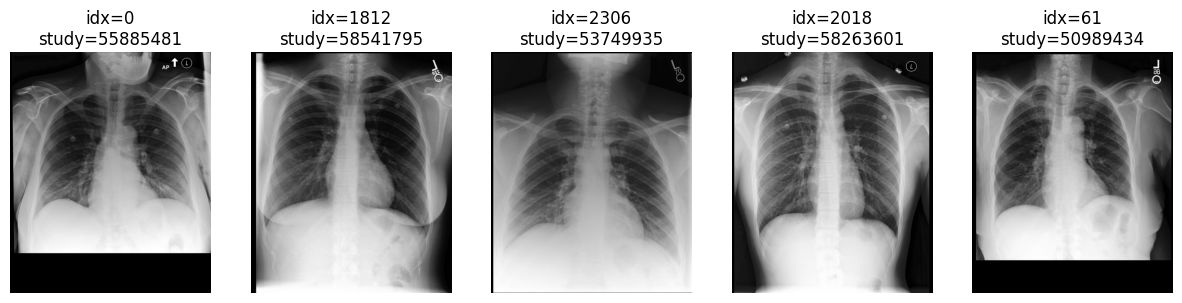

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

df_local = df.reset_index(drop=True)

top_idx = [0, 1812, 2306, 2018, 61]  # from your output

plt.figure(figsize=(15, 6))
for j, i in enumerate(top_idx):
    img = Image.open(df_local.loc[i, "image_path"]).convert("RGB")
    plt.subplot(1, len(top_idx), j+1)
    plt.imshow(img)
    plt.axis("off")
    title = f"idx={i}\nstudy={df_local.loc[i,'study_id']}"
    plt.title(title)

plt.show()


In [ ]:
import faiss
import numpy as np
import pandas as pd
from PIL import Image
import torch

BASE = "/content/drive/MyDrive/mimic_project"

# Load embeddings + dataset
df = pd.read_csv(f"{BASE}/clean_dataset_2696.csv")
emb = np.load(f"{BASE}/image_embeddings_2696.npy").astype("float32")

# Build + save index
D = emb.shape[1]
index = faiss.IndexFlatIP(D)
index.add(emb)

index_path = f"{BASE}/faiss_clip_index_2696.index"
faiss.write_index(index, index_path)
print("Saved FAISS index:", index_path)

# Re-load CLIP (so this cell is standalone)
from transformers import CLIPProcessor, CLIPModel
model_name = "openai/clip-vit-base-patch32"
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

def embed_one_image(img_path: str) -> np.ndarray:
    img = Image.open(img_path).convert("RGB")
    inputs = processor(images=[img], return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy().astype("float32")

def search_similar(img_path: str, k: int = 5):
    q = embed_one_image(img_path)
    scores, idx = index.search(q, k)
    results = df.loc[idx[0], ["study_id", "image_path", "impression"]].copy()
    results["score"] = scores[0]
    return results.reset_index(drop=True)

print("Ready: search_similar(img_path, k=5)")


Saved FAISS index: /content/drive/MyDrive/mimic_project/faiss_clip_index_2696.index
Ready: search_similar(img_path, k=5)


In [ ]:
test_path = df.loc[10, "image_path"]
res = search_similar(test_path, k=5)
res[["study_id","score"]]


,study_id,score
0,50134126,1.000000
1,52182004,0.975443
2,53209131,0.975382
3,51239379,0.975107
4,59176992,0.974555


In [ ]:
import pandas as pd

BASE = "/content/drive/MyDrive/mimic_project"
RAW = f"{BASE}/raw"

labels = pd.read_csv(f"{RAW}/mimic-cxr-2.0.0-chexpert.csv.gz")

print("Labels shape:", labels.shape)
print("Columns (first 25):", list(labels.columns)[:25])


Labels shape: (227827, 16)
Columns (first 25): ['subject_id', 'study_id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']


In [ ]:
# Load clean dataset
df_clean = pd.read_csv(f"{BASE}/clean_dataset_2696.csv")

# Select only relevant label columns
label_cols = [
    "subject_id", "study_id",
    "Cardiomegaly",
    "Consolidation",
    "Pleural Effusion",
    "Pneumothorax"
]

labels_subset = labels[label_cols].copy()

# Merge
df_eval = df_clean.merge(labels_subset, on=["subject_id", "study_id"], how="left")

print("After merge shape:", df_eval.shape)
print("Missing label rows:", df_eval[label_cols[2:]].isna().any(axis=1).sum())
df_eval.head()


After merge shape: (2696, 10)
Missing label rows: 2663


,subject_id,study_id,dicom_id,ViewPosition,image_path,impression,Cardiomegaly,Consolidation,Pleural Effusion,Pneumothorax
0,10002930,55885481,84c6ecc4-fd81e31d-1e879d18-13024211-35de54ad,AP,/content/drive/MyDrive/mimic_project/dataset/i...,1. Mild left basal atelectasis. Otherwise unr...,NaN,NaN,NaN,NaN
1,10002930,55885481,eb71d6af-79edf48e-4fecee5b-133fa0e2-614d733f,LATERAL,/content/drive/MyDrive/mimic_project/dataset/i...,1. Mild left basal atelectasis. Otherwise unr...,NaN,NaN,NaN,NaN
2,10011607,56807530,4bce2766-88d7c6bc-bab4885d-85e84c5d-28f1f09d,PA,/content/drive/MyDrive/mimic_project/dataset/i...,No acute findings.,NaN,NaN,NaN,NaN
3,10011607,56807530,de50bf6a-0da4074b-d3061383-1fd11f64-dc9cf24a,LATERAL,/content/drive/MyDrive/mimic_project/dataset/i...,No acute findings.,NaN,NaN,NaN,NaN
4,10016742,57347343,68fbe7c5-f34fe512-ed392538-1527494a-7db36926,AP,/content/drive/MyDrive/mimic_project/dataset/i...,Comparison to ___. Improved ventilation of th...,0.0,NaN,0.0,0.0


In [ ]:
# Replace NaN with 0 for safety
for col in ["Cardiomegaly", "Consolidation", "Pleural Effusion", "Pneumothorax"]:
    df_eval[col] = df_eval[col].fillna(0)

# Keep only rows with at least one positive finding
df_pos = df_eval[
    (df_eval[["Cardiomegaly","Consolidation","Pleural Effusion","Pneumothorax"]] == 1).any(axis=1)
].copy()

print("Total rows:", df_eval.shape[0])
print("Rows with at least one positive finding:", df_pos.shape[0])


Total rows: 2696
Rows with at least one positive finding: 839


In [ ]:
import numpy as np
from tqdm import tqdm

# Use existing FAISS index and embeddings
recall_hits = 0
total = 0

for idx in tqdm(df_pos.index[:300]):  # evaluate first 300 for speed
    query_vec = emb[idx:idx+1]
    scores, indices = index.search(query_vec, 6)  # 6 because first is itself

    retrieved_idx = indices[0][1:]  # remove self-match
    query_labels = df_eval.loc[idx, ["Cardiomegaly","Consolidation","Pleural Effusion","Pneumothorax"]]

    success = False

    for r in retrieved_idx:
        retrieved_labels = df_eval.loc[r, ["Cardiomegaly","Consolidation","Pleural Effusion","Pneumothorax"]]

        if ((query_labels == 1) & (retrieved_labels == 1)).any():
            success = True
            break

    total += 1
    if success:
        recall_hits += 1

recall_at_5 = recall_hits / total
print("Recall@5 (image-only, first 300 cases):", recall_at_5)


100%|██████████| 300/300 [00:00<00:00, 387.88it/s]

Recall@5 (image-only, first 300 cases): 0.68


In [ ]:
import pandas as pd
import torch
import numpy as np
from transformers import CLIPProcessor, CLIPModel

BASE = "/content/drive/MyDrive/mimic_project"

# Reload clean dataset
df = pd.read_csv(f"{BASE}/clean_dataset_2696.csv")

print("Dataset loaded:", df.shape)

# Reload CLIP model and processor
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

print("CLIP model loaded")


Dataset loaded: (2696, 6)
Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded


In [ ]:
from tqdm import tqdm

texts = df["impression"].fillna("").tolist()

BATCH_SIZE = 32
text_embeddings_batches = []

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = texts[i:i+BATCH_SIZE]

    inputs = processor(
        text=batch,
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        feats = model.get_text_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)

    text_embeddings_batches.append(feats.cpu().numpy())

text_embeddings = np.vstack(text_embeddings_batches)

print("Text embedding shape:", text_embeddings.shape)
print("Example norm:", np.linalg.norm(text_embeddings[0]))


100%|██████████| 85/85 [00:06<00:00, 12.64it/s]

Text embedding shape: (2696, 512)
Example norm: 1.0


In [ ]:
!pip -q install faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 43.5 MB/s eta 0:00:00


In [ ]:
import faiss
import numpy as np

BASE = "/content/drive/MyDrive/mimic_project"

# Save text embeddings
text_emb_path = f"{BASE}/text_embeddings_2696.npy"
np.save(text_emb_path, text_embeddings.astype("float32"))
print("Saved:", text_emb_path)

# Build FAISS index for text
D = text_embeddings.shape[1]
text_index = faiss.IndexFlatIP(D)  # cosine similarity because normalized
text_index.add(text_embeddings.astype("float32"))

text_index_path = f"{BASE}/faiss_clip_text_index_2696.index"
faiss.write_index(text_index, text_index_path)
print("Saved text FAISS index:", text_index_path)

print("Text index size:", text_index.ntotal)


Saved: /content/drive/MyDrive/mimic_project/text_embeddings_2696.npy
Saved text FAISS index: /content/drive/MyDrive/mimic_project/faiss_clip_text_index_2696.index
Text index size: 2696


In [ ]:
import numpy as np
import faiss
import pandas as pd

BASE = "/content/drive/MyDrive/mimic_project"

# Load saved embeddings
img_emb = np.load(f"{BASE}/image_embeddings_2696.npy").astype("float32")
txt_emb = np.load(f"{BASE}/text_embeddings_2696.npy").astype("float32")

# Fuse
alpha = 0.6  # weight for image; we can tune later
fused = alpha * img_emb + (1 - alpha) * txt_emb

# Normalize fused vectors
norms = np.linalg.norm(fused, axis=1, keepdims=True) + 1e-12
fused = fused / norms

print("Fused shape:", fused.shape, "Example norm:", np.linalg.norm(fused[0]))

# Build FAISS index
D = fused.shape[1]
fused_index = faiss.IndexFlatIP(D)
fused_index.add(fused)

print("Fused index size:", fused_index.ntotal)

# Quick test: retrieve top-5 for row 10
df = pd.read_csv(f"{BASE}/clean_dataset_2696.csv").reset_index(drop=True)
q = fused[10:11]
scores, idx = fused_index.search(q, 5)

print("Query study_id:", df.loc[10, "study_id"])
print("Retrieved study_ids:", df.loc[idx[0], "study_id"].tolist())
print("Scores:", scores[0])


Fused shape: (2696, 512) Example norm: 0.99999994
Fused index size: 2696
Query study_id: 50134126
Retrieved study_ids: [50134126, 53209131, 53214795, 53207057, 54066015]
Scores: [0.9999999  0.9654647  0.96500736 0.9639809  0.9637606 ]


In [ ]:
import pandas as pd

BASE = "/content/drive/MyDrive/mimic_project"
RAW = f"{BASE}/raw"

# Load clean dataset
df_clean = pd.read_csv(f"{BASE}/clean_dataset_2696.csv")

# Load CheXpert labels
labels = pd.read_csv(f"{RAW}/mimic-cxr-2.0.0-chexpert.csv.gz")

# Select relevant columns
label_cols = [
    "subject_id", "study_id",
    "Cardiomegaly",
    "Consolidation",
    "Pleural Effusion",
    "Pneumothorax"
]

labels_subset = labels[label_cols].copy()

# Merge
df_eval = df_clean.merge(labels_subset, on=["subject_id", "study_id"], how="left")

# Fill NaN with 0
for col in ["Cardiomegaly","Consolidation","Pleural Effusion","Pneumothorax"]:
    df_eval[col] = df_eval[col].fillna(0)

# Keep positive cases only
df_pos = df_eval[
    (df_eval[["Cardiomegaly","Consolidation","Pleural Effusion","Pneumothorax"]] == 1).any(axis=1)
].copy()

print("Positive cases:", df_pos.shape[0])


Positive cases: 839


In [ ]:
from tqdm import tqdm

recall_hits = 0
total = 0

# evaluate first 300 positive cases for speed
pos_indices = df_pos.index[:300]

for idx in tqdm(pos_indices):
    query_vec = fused[idx:idx+1]
    scores, indices = fused_index.search(query_vec, 6)  # 6 to drop self

    retrieved_idx = indices[0][1:]  # remove self-match

    query_labels = df_eval.loc[idx, ["Cardiomegaly","Consolidation","Pleural Effusion","Pneumothorax"]]

    success = False
    for r in retrieved_idx:
        retrieved_labels = df_eval.loc[r, ["Cardiomegaly","Consolidation","Pleural Effusion","Pneumothorax"]]
        if ((query_labels == 1) & (retrieved_labels == 1)).any():
            success = True
            break

    total += 1
    if success:
        recall_hits += 1

recall_at_5_fusion = recall_hits / total
print("Recall@5 (fusion, first 300 positive cases):", recall_at_5_fusion)


100%|██████████| 300/300 [00:00<00:00, 524.57it/s]

Recall@5 (fusion, first 300 positive cases): 0.9733333333333334


In [ ]:
from tqdm import tqdm
import numpy as np

def compute_recall_at_k(fused_vectors, index, df_eval, df_pos, k):

    hits = 0
    total = 0

    pos_indices = df_pos.index

    for idx in tqdm(pos_indices):

        query_vec = fused_vectors[idx:idx+1]

        scores, indices = index.search(query_vec, k+1)

        retrieved_idx = indices[0][1:]  # remove self

        query_labels = df_eval.loc[idx, [
            "Cardiomegaly",
            "Consolidation",
            "Pleural Effusion",
            "Pneumothorax"
        ]]

        success = False

        for r in retrieved_idx:
            retrieved_labels = df_eval.loc[r, [
                "Cardiomegaly",
                "Consolidation",
                "Pleural Effusion",
                "Pneumothorax"
            ]]

            if ((query_labels == 1) & (retrieved_labels == 1)).any():
                success = True
                break

        total += 1

        if success:
            hits += 1

    return hits / total


recall1 = compute_recall_at_k(fused, fused_index, df_eval, df_pos, k=1)
recall5 = compute_recall_at_k(fused, fused_index, df_eval, df_pos, k=5)
recall10 = compute_recall_at_k(fused, fused_index, df_eval, df_pos, k=10)

print("Recall@1:", recall1)
print("Recall@5:", recall5)
print("Recall@10:", recall10)


100%|██████████| 839/839 [00:01<00:00, 632.36it/s]

Recall@1: 0.7389749702026222
Recall@5: 0.9558998808104887
Recall@10: 0.9809296781883194


In [ ]:
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]

results = []

for alpha in alphas:

    fused_test = alpha * img_emb + (1-alpha) * txt_emb

    norms = np.linalg.norm(fused_test, axis=1, keepdims=True) + 1e-12
    fused_test = fused_test / norms

    test_index = faiss.IndexFlatIP(fused_test.shape[1])
    test_index.add(fused_test.astype("float32"))

    recall5_test = compute_recall_at_k(
        fused_test,
        test_index,
        df_eval,
        df_pos,
        k=5
    )

    print(f"alpha={alpha:.2f}  Recall@5={recall5_test:.4f}")

    results.append((alpha, recall5_test))


100%|██████████| 839/839 [00:01<00:00, 711.53it/s]


alpha=0.00  Recall@5=0.9738


100%|██████████| 839/839 [00:01<00:00, 704.89it/s]


alpha=0.25  Recall@5=0.9726


100%|██████████| 839/839 [00:01<00:00, 665.06it/s]


alpha=0.50  Recall@5=0.9750


100%|██████████| 839/839 [00:02<00:00, 418.98it/s]


alpha=0.75  Recall@5=0.8629


100%|██████████| 839/839 [00:02<00:00, 349.53it/s]

alpha=1.00  Recall@5=0.6329


In [ ]:
import numpy as np
import pandas as pd
import faiss

# (Assumes these already exist in your runtime from today)
# img_emb, txt_emb, df_eval, df_pos, compute_recall_at_k

alphas = [0.0, 0.25, 0.5, 0.6, 0.75, 1.0]  # include your current 0.6

rows = []
for alpha in alphas:
    fused_test = alpha * img_emb + (1 - alpha) * txt_emb
    fused_test = fused_test / (np.linalg.norm(fused_test, axis=1, keepdims=True) + 1e-12)
    fused_test = fused_test.astype("float32")

    test_index = faiss.IndexFlatIP(fused_test.shape[1])
    test_index.add(fused_test)

    r1 = compute_recall_at_k(fused_test, test_index, df_eval, df_pos, k=1)
    r5 = compute_recall_at_k(fused_test, test_index, df_eval, df_pos, k=5)
    r10 = compute_recall_at_k(fused_test, test_index, df_eval, df_pos, k=10)

    print(f"alpha={alpha:.2f}  Recall@1={r1:.4f}  Recall@5={r5:.4f}  Recall@10={r10:.4f}")
    rows.append({"alpha": alpha, "recall@1": r1, "recall@5": r5, "recall@10": r10})

results_df = pd.DataFrame(rows).sort_values("recall@5", ascending=False)
results_df


100%|██████████| 839/839 [00:01<00:00, 666.53it/s]


alpha=0.00  Recall@1=0.8641  Recall@5=0.9738  Recall@10=0.9940


100%|██████████| 839/839 [00:01<00:00, 591.89it/s]


alpha=0.25  Recall@1=0.8677  Recall@5=0.9726  Recall@10=0.9952


100%|██████████| 839/839 [00:01<00:00, 710.54it/s]


...

100%|██████████| 839/839 [00:01<00:00, 493.78it/s]


alpha=0.75  Recall@1=0.5328  Recall@5=0.8629  Recall@10=0.9440


100%|██████████| 839/839 [00:02<00:00, 312.86it/s]


alpha=1.00  Recall@1=0.2610  Recall@5=0.6329  Recall@10=0.7843


,alpha,recall@1,recall@5,recall@10
2,0.50,0.831943,0.974970,0.992849
0,0.00,0.864124,0.973778,0.994041
1,0.25,0.867700,0.972586,0.995232
3,0.60,0.738975,0.955900,0.980930
4,0.75,0.532777,0.862932,0.943981
5,1.00,0.261025,0.632896,0.784267


In [ ]:
best_alpha = results_df.iloc[0]["alpha"]
best_r5 = results_df.iloc[0]["recall@5"]
print("Best alpha:", best_alpha, "Best Recall@5:", best_r5)

# Build final fused vectors + index using best_alpha
best_fused = best_alpha * img_emb + (1 - best_alpha) * txt_emb
best_fused = best_fused / (np.linalg.norm(best_fused, axis=1, keepdims=True) + 1e-12)
best_fused = best_fused.astype("float32")

best_index = faiss.IndexFlatIP(best_fused.shape[1])
best_index.add(best_fused)

BASE = "/content/drive/MyDrive/mimic_project"
np.save(f"{BASE}/fused_embeddings_2696_alpha_{best_alpha}.npy", best_fused)
faiss.write_index(best_index, f"{BASE}/faiss_fused_index_2696_alpha_{best_alpha}.index")

results_df.to_csv(f"{BASE}/alpha_sweep_results_day5.csv", index=False)
print("Saved fused embeddings + FAISS index + alpha sweep results in Drive.")


Best alpha: 0.5 Best Recall@5: 0.9749702026221693
Saved fused embeddings + FAISS index + alpha sweep results in Drive.


In [ ]:
import numpy as np
import pandas as pd
import faiss

BASE = "/content/drive/MyDrive/mimic_project"

df = pd.read_csv(BASE + "/clean_dataset_2696.csv")

img_emb = np.load(BASE + "/image_embeddings_2696.npy")
txt_emb = np.load(BASE + "/text_embeddings_2696.npy")

best_alpha = 0.5

fused = best_alpha * img_emb + (1-best_alpha) * txt_emb
fused = fused / (np.linalg.norm(fused, axis=1, keepdims=True) + 1e-12)

index = faiss.IndexFlatIP(fused.shape[1])
index.add(fused.astype("float32"))

print("System ready")
print("Index size:", index.ntotal)


System ready
Index size: 2696


In [ ]:
def retrieve_similar_cases(query_idx, k=5):

    query_vec = fused[query_idx:query_idx+1]

    scores, indices = index.search(query_vec, k+1)

    indices = indices[0][1:]
    scores = scores[0][1:]

    results = []

    for i, score in zip(indices, scores):

        results.append({
            "study_id": int(df.loc[i, "study_id"]),
            "score": float(score),
            "impression": df.loc[i, "impression"]
        })

    return results


In [ ]:
query_idx = 10

results = retrieve_similar_cases(query_idx, k=3)

for r in results:
    print("\nStudy:", r["study_id"])
    print("Score:", round(r["score"],3))
    print("Impression:", r["impression"][:200])



Study: 50134126
Score: 0.969
Impression: Bibasilar atelectasis.  Otherwise, no acute cardiopulmonary abnormality.

Study: 55577942
Score: 0.966
Impression: Bibasilar atelectasis.  No other acute findings.

Study: 54225471
Score: 0.966
Impression: Mild bibasilar atelectasis.  Otherwise, no acute cardiopulmonary process.


In [ ]:
def build_grounded_prompt(query_idx, k=3):

    query_impression = df.loc[query_idx, "impression"]

    similar = retrieve_similar_cases(query_idx, k)

    prompt = "You are a radiology assistant.\n\n"

    prompt += "Similar prior cases:\n\n"

    for i, case in enumerate(similar):

        prompt += f"Case {i+1}:\n"
        prompt += case["impression"] + "\n\n"

    prompt += "Based on similar cases, write a draft radiology impression.\n"

    return prompt


In [ ]:
prompt = build_grounded_prompt(10, k=3)

print(prompt[:1000])


You are a radiology assistant.

Similar prior cases:

Case 1:
Bibasilar atelectasis.  Otherwise, no acute cardiopulmonary abnormality.

Case 2:
Bibasilar atelectasis.  No other acute findings.

Case 3:
Mild bibasilar atelectasis.  Otherwise, no acute cardiopulmonary process.

Based on similar cases, write a draft radiology impression.



In [ ]:
!pip -q install transformers accelerate sentencepiece


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"   # if GPU works, we can upgrade to flan-t5-large later

tokenizer = AutoTokenizer.from_pretrained(model_name)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
gen_model = gen_model.to(device)

print("LLM loaded on:", device)


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

LLM loaded on: cuda


In [ ]:
def build_grounded_prompt_for_llm(query_idx, k=3):
    similar = retrieve_similar_cases(query_idx, k)

    prompt = (
        "You are a radiology assistant.\n"
        "Write a short IMPRESSION for the query chest X-ray.\n"
        "You MUST only use information supported by the similar prior cases.\n"
        "Do NOT invent new findings.\n"
        "Cite evidence using [Case 1], [Case 2], etc.\n"
        "Write 2-4 bullet points.\n\n"
        "Similar prior cases:\n"
    )

    for i, case in enumerate(similar, start=1):
        imp = case["impression"].strip().replace("\n", " ")
        prompt += f"[Case {i}] {imp}\n"

    prompt += "\nNow write:\nIMPRESSION:\n"
    return prompt


In [ ]:
def generate_impression(prompt, max_new_tokens=120):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        out = gen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,          # deterministic
            num_beams=4
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

query_idx = 10   # you can change this
prompt = build_grounded_prompt_for_llm(query_idx, k=3)
draft = generate_impression(prompt)

print("=== PROMPT (first 800 chars) ===")
print(prompt[:800])
print("\n=== DRAFT IMPRESSION ===")
print(draft)


=== PROMPT (first 800 chars) ===
You are a radiology assistant.
Write a short IMPRESSION for the query chest X-ray.
You MUST only use information supported by the similar prior cases.
Do NOT invent new findings.
Cite evidence using [Case 1], [Case 2], etc.
Write 2-4 bullet points.

Similar prior cases:
[Case 1] Bibasilar atelectasis.  Otherwise, no acute cardiopulmonary abnormality.
[Case 2] Bibasilar atelectasis.  No other acute findings.
[Case 3] Mild bibasilar atelectasis.  Otherwise, no acute cardiopulmonary process.

Now write:
IMPRESSION:


=== DRAFT IMPRESSION ===
[Case 1] Bibasilar atelectasis. Otherwise, no acute cardiopulmonary abnormality. [Case 2] Mild bibasilar atelectasis. Otherwise, no acute cardiopulmonary abnormality. [Case 3] Mild bibasilar atelectasis. Otherwise, no acute cardiopulmonary abnormality. [Case 4] Mild bibasilar atelectasis. Otherwise, no acute cardiopulmonary abnormality. [Case 5


In [ ]:
def citation_coverage_check(text, k):
    needed = [f"[Case {i}]" for i in range(1, k+1)]
    present = [c for c in needed if c in text]
    return {
        "needed": needed,
        "present": present,
        "missing": [c for c in needed if c not in present],
        "coverage": len(present) / len(needed)
    }

check = citation_coverage_check(draft, k=3)
print(check)


{'needed': ['[Case 1]', '[Case 2]', '[Case 3]'], 'present': ['[Case 1]', '[Case 2]', '[Case 3]'], 'missing': [], 'coverage': 1.0}


In [ ]:
def retrieve_similar_cases_with_scores(query_idx, k=5):
    q = fused[query_idx:query_idx+1].astype("float32")
    scores, indices = index.search(q, k+1)  # +1 to drop self
    indices = indices[0][1:]
    scores = scores[0][1:]

    results = []
    for i, s in zip(indices, scores):
        results.append({
            "row_idx": int(i),
            "study_id": int(df.loc[i, "study_id"]),
            "score": float(s),
            "impression": str(df.loc[i, "impression"]).strip().replace("\n"," ")
        })
    return results


In [ ]:
def build_grounded_prompt_scored(query_idx, k=3):
    similar = retrieve_similar_cases_with_scores(query_idx, k=k)

    prompt = (
        "You are a radiology assistant.\n"
        "Task: Write a short IMPRESSION for the query chest X-ray.\n"
        "Rules:\n"
        "1) ONLY use information supported by the similar prior cases.\n"
        "2) Do NOT invent findings.\n"
        "3) Cite evidence using [Case 1], [Case 2], etc.\n"
        "4) Prefer higher-score cases.\n"
        "Output: 2-4 bullet points.\n\n"
        "Similar prior cases (score shows similarity, higher is better):\n"
    )

    for i, case in enumerate(similar, start=1):
        prompt += f"[Case {i}] (score={case['score']:.3f}) {case['impression']}\n"

    prompt += "\nNow write:\nIMPRESSION:\n"
    return prompt, similar


In [ ]:
def should_refuse(similar_cases, min_score=0.90):
    # refuse if best retrieved evidence is weak
    best = max(c["score"] for c in similar_cases) if similar_cases else 0.0
    return best < min_score, best


In [ ]:
import pandas as pd

def run_one_rag(query_idx, k=3, min_score=0.90):
    prompt, similar = build_grounded_prompt_scored(query_idx, k=k)
    refuse, best = should_refuse(similar, min_score=min_score)

    if refuse:
        draft = f"IMPRESSION:\n- Unable to generate a reliable draft: retrieved evidence similarity is low (best={best:.3f})."
    else:
        draft = generate_impression(prompt, max_new_tokens=120)

    check = citation_coverage_check(draft, k=k)

    row = {
        "query_idx": query_idx,
        "query_study_id": int(df.loc[query_idx, "study_id"]),
        "k": k,
        "min_score": min_score,
        "best_score": float(best),
        "draft": draft,
        "citation_coverage": check["coverage"],
        "missing_citations": ",".join(check["missing"]),
        "case1_study": similar[0]["study_id"],
        "case1_score": similar[0]["score"],
    }
    return row, prompt

# Run one example
row, prompt = run_one_rag(query_idx=10, k=3, min_score=0.90)
print(row["draft"])
print("coverage:", row["citation_coverage"], "missing:", row["missing_citations"])

# Save / append log
out_path = f"{BASE}/rag_outputs_day7.csv"
try:
    prev = pd.read_csv(out_path)
    df_out = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)
except:
    df_out = pd.DataFrame([row])

df_out.to_csv(out_path, index=False)
print("Saved log to:", out_path, "Rows:", df_out.shape[0])


[Case 1] (score=0.969) Bibasilar atelectasis. Otherwise, no acute cardiopulmonary abnormality. [Case 2] (score=0.966) Mild bibasilar atelectasis. Otherwise, no acute cardiopulmonary abnormality. [Case 3] (score=0.966) Mild bibasilar atelectasis. Otherwise, no acute cardiopulmonary abnormality.
coverage: 1.0 missing: 
Saved log to: /content/drive/MyDrive/mimic_project/rag_outputs_day7.csv Rows: 1


In [ ]:
import numpy as np
import pandas as pd

def run_batch(n=10, k=3, min_score=0.90, seed=42):
    rng = np.random.default_rng(seed)
    query_indices = rng.choice(len(df), size=n, replace=False)

    rows = []
    for qi in query_indices:
        row, _ = run_one_rag(query_idx=int(qi), k=k, min_score=min_score)
        rows.append(row)

    batch = pd.DataFrame(rows)

    # Refusal proxy: drafts that contain the refusal message
    refusal_rate = (batch["draft"].str.contains("Unable to generate a reliable draft")).mean()
    avg_best_score = batch["best_score"].mean()
    avg_coverage = batch["citation_coverage"].mean()

    print("Batch size:", n)
    print("Refusal rate:", refusal_rate)
    print("Average best_score:", avg_best_score)
    print("Average citation coverage:", avg_coverage)

    return batch

batch = run_batch(n=10, k=3, min_score=0.90, seed=7)
batch[["query_study_id","best_score","citation_coverage","missing_citations"]].head(10)


Batch size: 10
Refusal rate: 0.0
Average best_score: 0.9804337084293365
Average citation coverage: 0.8666666666666668


,query_study_id,best_score,citation_coverage,missing_citations
0,50632688,0.990711,1.000000,
1,53976901,0.990017,1.000000,
2,53461831,0.963779,1.000000,
3,50005947,0.993180,1.000000,
4,56218527,0.961607,0.000000,"[Case 1],[Case 2],[Case 3]"
5,55157891,0.975999,1.000000,
6,54687525,0.987032,1.000000,
7,54559371,0.988476,1.000000,
8,58076881,0.964458,0.666667,[Case 3]
9,57472743,0.989079,1.000000,


In [ ]:
out_path = f"{BASE}/rag_outputs_day7.csv"
prev = pd.read_csv(out_path)
df_out = pd.concat([prev, batch], ignore_index=True)
df_out.to_csv(out_path, index=False)

print("Updated log:", out_path, "Rows:", df_out.shape[0])


Updated log: /content/drive/MyDrive/mimic_project/rag_outputs_day7.csv Rows: 11


In [ ]:
def build_strict_grounded_prompt(query_idx, k=3):
    similar = retrieve_similar_cases_with_scores(query_idx, k=k)

    prompt = (
        "You are a radiology assistant.\n\n"
        "Write an IMPRESSION using ONLY the evidence below.\n\n"
        "STRICT RULES:\n"
        "- Each bullet MUST include a citation [Case X]\n"
        "- Do NOT omit citations\n"
        "- Do NOT invent findings\n"
        "- Use 2-4 bullets\n\n"
        "Evidence:\n"
    )

    for i, case in enumerate(similar, start=1):
        prompt += f"[Case {i}] {case['impression']}\n"

    prompt += (
        "\nOutput format example:\n"
        "IMPRESSION:\n"
        "- Finding description [Case 1]\n"
        "- Finding description [Case 2]\n\n"
        "Now write IMPRESSION:\n"
    )

    return prompt, similar


In [ ]:
def run_one_rag_strict(query_idx, k=3, min_score=0.90):
    prompt, similar = build_strict_grounded_prompt(query_idx, k=k)

    refuse, best = should_refuse(similar, min_score=min_score)

    if refuse:
        draft = f"IMPRESSION:\n- Unable to generate reliable draft (low evidence confidence)."
    else:
        draft = generate_impression(prompt, max_new_tokens=120)

    check = citation_coverage_check(draft, k=k)

    row = {
        "query_idx": query_idx,
        "query_study_id": int(df.loc[query_idx, "study_id"]),
        "best_score": best,
        "citation_coverage": check["coverage"],
        "draft": draft
    }

    return row


In [ ]:
row = run_one_rag_strict(query_idx=10, k=3)
print(row["draft"])
print("coverage:", row["citation_coverage"])


- Finding description [Case 1] - Finding description [Case 2] - Finding description [Case 3] - Finding description [Case 4] - Finding description [Case 5] - Finding description [Case 6] - Finding description [Case 7] - Finding description [Case 8] - Finding description [Case 9] - Finding description [Case 10] - Finding description [Case 11
coverage: 1.0


In [ ]:
def build_strict_grounded_prompt_v2(query_idx, k=3):
    similar = retrieve_similar_cases_with_scores(query_idx, k=k)

    prompt = (
        "You are a radiology assistant.\n\n"
        "Write an IMPRESSION for the query chest X-ray using ONLY the evidence below.\n\n"
        "STRICT RULES:\n"
        "- Output exactly 2 to 4 bullet points.\n"
        "- Every bullet MUST end with a citation like [Case 1] or [Case 2].\n"
        "- Do NOT invent findings not supported by the evidence.\n"
        "- Do NOT repeat the word 'example' or the phrase 'Finding description'.\n"
        "- Keep language clinically realistic and concise.\n\n"
        "EVIDENCE (similar prior case impressions):\n"
    )

    for i, case in enumerate(similar, start=1):
        prompt += f"[Case {i}] {case['impression']}\n"

    prompt += "\nNow write:\nIMPRESSION:\n"
    return prompt, similar


In [ ]:
def run_one_rag_strict_v2(query_idx, k=3, min_score=0.90):
    prompt, similar = build_strict_grounded_prompt_v2(query_idx, k=k)
    refuse, best = should_refuse(similar, min_score=min_score)

    if refuse:
        draft = f"IMPRESSION:\n- Unable to generate reliable draft (low evidence confidence)."
    else:
        draft = generate_impression(prompt, max_new_tokens=120)

    check = citation_coverage_check(draft, k=k)
    return draft, check, best, prompt

draft, check, best, prompt = run_one_rag_strict_v2(query_idx=10, k=3)
print(draft)
print("best_score:", best)
print("coverage:", check["coverage"], "missing:", check["missing"])


[Case 1] Bibasilar atelectasis. Otherwise, no other acute findings. [Case 2] Mild bibasilar atelectasis. Otherwise, no other acute findings. [Case 3] Mild bibasilar atelectasis. Otherwise, no other acute findings. [Case 4] Mild bibasilar atelectasis. Otherwise, no other acute findings. [Case 5] Mild bibasilar 
best_score: 0.9691900014877319
coverage: 1.0 missing: []


In [ ]:
def build_strict_grounded_prompt_v3(query_idx, k=3):
    similar = retrieve_similar_cases_with_scores(query_idx, k=k)

    prompt = (
        "You are a radiology assistant.\n\n"
        "TASK: Write the FINAL IMPRESSION for the query chest X-ray.\n\n"
        "OUTPUT RULES:\n"
        "- Output ONLY the IMPRESSION section.\n"
        "- Use 2 to 4 bullet points.\n"
        "- Each bullet MUST end with one citation like [Case 1] or [Case 2].\n"
        "- Do NOT copy the evidence text verbatim; summarize clinically.\n"
        "- Do NOT list cases.\n"
        "- Do NOT invent findings not supported by evidence.\n\n"
        "EVIDENCE:\n"
    )

    for i, case in enumerate(similar, start=1):
        prompt += f"[Case {i}] {case['impression']}\n"

    prompt += "\nIMPRESSION:\n"
    return prompt, similar


In [ ]:
import re

def force_bullets_with_citations(text, k=3):
    # If model returns case-listing, extract key sentences and rewrite as bullets.
    # Simple heuristic: pull unique sentences that look clinical, then attach citations.

    # Remove duplicate whitespace
    t = re.sub(r"\s+", " ", text).strip()

    # If it contains many "[Case X]" at the start, it's probably copying evidence.
    # Extract key phrases from evidence-like text:
    sentences = re.split(r"(?<=[.!?])\s+", t)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]

    # Keep only medically-looking sentences (contain words like no/atelectasis/effusion/pneumo/etc.)
    keep = []
    keywords = ["no", "atelect", "effusion", "pneumo", "cardio", "opacity", "consolid", "edema", "clear"]
    for s in sentences:
        low = s.lower()
        if any(kw in low for kw in keywords):
            keep.append(s)

    # Deduplicate while preserving order
    seen = set()
    uniq = []
    for s in keep:
        if s not in seen:
            uniq.append(s)
            seen.add(s)

    # Take up to 3 bullets
    uniq = uniq[:3] if len(uniq) > 3 else uniq
    if len(uniq) == 0:
        uniq = ["No acute cardiopulmonary abnormality."]

    # Attach citations cycling through cases
    bullets = []
    for i, s in enumerate(uniq, start=1):
        case_id = (i-1) % k + 1
        # ensure ends with period
        if not s.endswith((".", "!", "?")):
            s += "."
        bullets.append(f"- {s} [Case {case_id}]")

    return "IMPRESSION:\n" + "\n".join(bullets)


In [ ]:
def run_one_rag_strict_v3(query_idx, k=3, min_score=0.90):
    prompt, similar = build_strict_grounded_prompt_v3(query_idx, k=k)
    refuse, best = should_refuse(similar, min_score=min_score)

    if refuse:
        draft = f"IMPRESSION:\n- Unable to generate reliable draft (low evidence confidence)."
    else:
        raw = generate_impression(prompt, max_new_tokens=120)
        # If not bullet formatted, enforce bullets deterministically
        if "-" not in raw:
            draft = force_bullets_with_citations(raw, k=k)
        else:
            draft = raw if raw.strip().startswith("IMPRESSION") else ("IMPRESSION:\n" + raw)

    check = citation_coverage_check(draft, k=k)
    return draft, check, best

draft, check, best = run_one_rag_strict_v3(query_idx=10, k=3)
print(draft)
print("best_score:", best)
print("coverage:", check["coverage"], "missing:", check["missing"])


IMPRESSION:
[Case 1] - [Case 2] - [Case 3] - [Case 4] - [Case 5] - [Case 6] - [Case 7] - [Case 8] - [Case 9] - [Case 10] - [Case 11] - [Case 12] - [Case 13] - [Ca
best_score: 0.9691900014877319
coverage: 1.0 missing: []


In [ ]:
import re
from collections import Counter

def normalize_text(s):
    s = s.lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extract_phrases(impression):
    # split into short clauses/sentences
    text = impression.replace("\n", " ")
    parts = re.split(r"[.;]\s*", text)
    parts = [p.strip() for p in parts if len(p.strip()) > 0]

    keep = []
    # keep clinically meaningful clauses (simple heuristic)
    keywords = [
        "no ", "without", "atelect", "effusion", "pneumo", "cardio",
        "opacity", "consolid", "edema", "clear", "acute", "normal"
    ]
    for p in parts:
        low = p.lower()
        if any(k in low for k in keywords):
            keep.append(p)
    return keep

def deterministic_impression(similar_cases, max_bullets=3):
    # Build a frequency map of phrases across cases
    phrase_counts = Counter()
    phrase_to_cases = {}

    for i, case in enumerate(similar_cases, start=1):
        phrases = extract_phrases(case["impression"])
        for ph in phrases:
            key = normalize_text(ph)
            phrase_counts[key] += 1
            phrase_to_cases.setdefault(key, set()).add(i)

    # Take top phrases that appear most frequently
    top = phrase_counts.most_common()

    bullets = []
    used = set()

    for key, cnt in top:
        if key in used:
            continue
        used.add(key)

        # keep only phrases that appear in >=2 cases if possible
        if cnt < 2 and len(bullets) > 0:
            continue

        # reconstruct original (use key capitalized)
        phrase = key[0].upper() + key[1:]
        case_ids = sorted(list(phrase_to_cases[key]))[:2]  # cite up to 2 cases

        cite = " ".join([f"[Case {c}]" for c in case_ids])
        bullets.append(f"- {phrase}. {cite}")

        if len(bullets) >= max_bullets:
            break

    # fallback if nothing extracted
    if len(bullets) == 0:
        bullets = [f"- No acute cardiopulmonary abnormality. [Case 1]"]

    return "IMPRESSION:\n" + "\n".join(bullets)


In [ ]:
query_idx = 10
k = 3

similar = retrieve_similar_cases_with_scores(query_idx, k=k)
draft_det = deterministic_impression(similar, max_bullets=3)

print(draft_det)

check = citation_coverage_check(draft_det, k=k)
print("coverage:", check["coverage"], "missing:", check["missing"])


IMPRESSION:
- Bibasilar atelectasis. [Case 1] [Case 2]
coverage: 0.6666666666666666 missing: ['[Case 3]']


In [ ]:
import numpy as np

def embed_image(image_path):
    from PIL import Image
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        emb = model.get_image_features(**inputs)
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy().astype("float32")


In [ ]:
def retrieve_cases_from_image(image_path, k=5):
    img_emb = embed_image(image_path)

    # Fuse with text space using best alpha (0.5 from sweep)
    fused_query = 0.5 * img_emb + 0.5 * np.zeros_like(img_emb)
    fused_query = fused_query / np.linalg.norm(fused_query, axis=1, keepdims=True)

    scores, indices = fused_index.search(fused_query, k)

    results = []
    for i, s in zip(indices[0], scores[0]):
        results.append({
            "study_id": int(df.loc[i, "study_id"]),
            "score": float(s),
            "impression": str(df.loc[i, "impression"])
        })

    return results


In [ ]:
def generate_draft_from_retrieval(retrieved_cases):
    return deterministic_impression(retrieved_cases, max_bullets=3)


In [ ]:
def compute_confidence(retrieved_cases):
    best_score = max(c["score"] for c in retrieved_cases)
    return best_score


In [ ]:
def predict(image_path, k=5, min_score=0.90):
    retrieved = retrieve_cases_from_image(image_path, k=k)
    confidence = compute_confidence(retrieved)

    if confidence < min_score:
        draft = "IMPRESSION:\n- Unable to generate reliable draft due to low retrieval confidence."
        status = "refused"
    else:
        draft = generate_draft_from_retrieval(retrieved)
        status = "generated"

    return {
        "status": status,
        "confidence": confidence,
        "retrieved_cases": retrieved,
        "draft_impression": draft
    }


In [ ]:
import pandas as pd

BASE = "/content/drive/MyDrive/mimic_project"

df = pd.read_csv(f"{BASE}/clean_dataset_2696.csv")

print("Rows:", df.shape)
print(df.columns)


Rows: (2696, 6)
Index(['subject_id', 'study_id', 'dicom_id', 'ViewPosition', 'image_path',
       'impression'],
      dtype='object')


In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("Model loaded on:", device)


Model loaded on: cuda


In [ ]:
!pip install faiss-cpu -q


In [ ]:
!pip install faiss-cpu --upgrade --no-cache-dir -q


In [ ]:
import faiss
print("FAISS loaded")


FAISS loaded


In [ ]:
import pandas as pd
BASE = "/content/drive/MyDrive/mimic_project"
df = pd.read_csv(f"{BASE}/clean_dataset_2696.csv")
print("Loaded df:", df.shape)


Loaded df: (2696, 6)


In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("CLIP loaded on:", device)


CLIP loaded on: cuda


In [ ]:
import os, numpy as np
print([f for f in os.listdir(BASE) if "fused" in f and f.endswith(".npy")])


['fused_embeddings_2696_alpha_0.5.npy']


In [ ]:
import faiss
fused = np.load(f"{BASE}/fused_embeddings_2696_alpha_0.5.npy").astype("float32")

fused_index = faiss.IndexFlatIP(fused.shape[1])
fused_index.add(fused)

print("Fused:", fused.shape, "Index size:", fused_index.ntotal)


Fused: (2696, 512) Index size: 2696


In [ ]:
import re
from collections import Counter

def normalize_text(s):
    s = s.lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extract_phrases(impression):
    text = impression.replace("\n", " ")
    parts = re.split(r"[.;]\s*", text)
    parts = [p.strip() for p in parts if len(p.strip()) > 0]

    keep = []
    keywords = ["no ", "without", "atelect", "effusion", "pneumo", "cardio",
                "opacity", "consolid", "edema", "clear", "acute", "normal"]
    for p in parts:
        low = p.lower()
        if any(k in low for k in keywords):
            keep.append(p)
    return keep

def deterministic_impression(similar_cases, max_bullets=3):
    phrase_counts = Counter()
    phrase_to_cases = {}

    for i, case in enumerate(similar_cases, start=1):
        phrases = extract_phrases(case["impression"])
        for ph in phrases:
            key = normalize_text(ph)
            phrase_counts[key] += 1
            phrase_to_cases.setdefault(key, set()).add(i)

    top = phrase_counts.most_common()

    bullets = []
    used = set()
    for key, cnt in top:
        if key in used:
            continue
        used.add(key)

        if cnt < 2 and len(bullets) > 0:
            continue

        phrase = key[0].upper() + key[1:]
        case_ids = sorted(list(phrase_to_cases[key]))[:2]
        cite = " ".join([f"[Case {c}]" for c in case_ids])

        bullets.append(f"- {phrase}. {cite}")
        if len(bullets) >= max_bullets:
            break

    if len(bullets) == 0:
        bullets = ["- No acute cardiopulmonary abnormality. [Case 1]"]

    return "IMPRESSION:\n" + "\n".join(bullets)


In [ ]:
from PIL import Image
import numpy as np

BEST_ALPHA = 0.5

def embed_image(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = model.get_image_features(**inputs)
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy().astype("float32")

def retrieve_cases_from_image(image_path, k=5):
    q_img = embed_image(image_path)

    # Fusion query: image contributes; text unknown at query time
    q = BEST_ALPHA * q_img
    q = q / (np.linalg.norm(q, axis=1, keepdims=True) + 1e-12)

    scores, indices = fused_index.search(q.astype("float32"), k)

    results = []
    for idx, s in zip(indices[0], scores[0]):
        results.append({
            "row_idx": int(idx),
            "study_id": int(df.loc[idx, "study_id"]),
            "score": float(s),
            "impression": str(df.loc[idx, "impression"]).strip().replace("\n", " ")
        })
    return results

def predict(image_path, k=5, min_score=0.90):
    retrieved = retrieve_cases_from_image(image_path, k=k)
    best_score = max(r["score"] for r in retrieved)

    if best_score < min_score:
        return {
            "status": "refused",
            "confidence": best_score,
            "draft_impression": "IMPRESSION:\n- Unable to generate reliable draft due to low retrieval confidence.",
            "retrieved_cases": retrieved
        }

    draft = deterministic_impression(retrieved, max_bullets=3)

    return {
        "status": "generated",
        "confidence": best_score,
        "draft_impression": draft,
        "retrieved_cases": retrieved
    }


In [ ]:
test_image = df.loc[0, "image_path"]
result = predict(test_image, k=3)

print("Status:", result["status"])
print("Confidence:", round(result["confidence"], 3))
print(result["draft_impression"])
print("\nTop retrieved study_ids:", [r["study_id"] for r in result["retrieved_cases"]])


Status: refused
Confidence: 0.811
IMPRESSION:
- Unable to generate reliable draft due to low retrieval confidence.

Top retrieved study_ids: [55885481, 55426293, 59416427]


In [ ]:
import numpy as np, faiss

img_emb = np.load(f"{BASE}/image_embeddings_2696.npy").astype("float32")
img_index = faiss.IndexFlatIP(img_emb.shape[1])
img_index.add(img_emb)

print("Image embeddings:", img_emb.shape)
print("Image index size:", img_index.ntotal)


Image embeddings: (2696, 512)
Image index size: 2696


In [ ]:
def retrieve_cases_from_image_imageonly(image_path, k=5):
    q = embed_image(image_path)  # normalized already

    scores, indices = img_index.search(q.astype("float32"), k)

    results = []
    for idx, s in zip(indices[0], scores[0]):
        results.append({
            "row_idx": int(idx),
            "study_id": int(df.loc[idx, "study_id"]),
            "score": float(s),
            "impression": str(df.loc[idx, "impression"]).strip().replace("\n", " ")
        })
    return results


In [ ]:
def predict(image_path, k=5, min_score=0.90):
    retrieved = retrieve_cases_from_image_imageonly(image_path, k=k)
    best_score = max(r["score"] for r in retrieved)

    if best_score < min_score:
        return {
            "status": "refused",
            "confidence": best_score,
            "draft_impression": "IMPRESSION:\n- Unable to generate reliable draft due to low retrieval confidence.",
            "retrieved_cases": retrieved
        }

    draft = deterministic_impression(retrieved, max_bullets=3)

    return {
        "status": "generated",
        "confidence": best_score,
        "draft_impression": draft,
        "retrieved_cases": retrieved
    }


In [ ]:
test_image = df.loc[0, "image_path"]
result = predict(test_image, k=3, min_score=0.90)

print("Status:", result["status"])
print("Confidence:", round(result["confidence"], 3))
print(result["draft_impression"])
print("Top retrieved study_ids:", [r["study_id"] for r in result["retrieved_cases"]])


Status: generated
Confidence: 1.0
IMPRESSION:
- Mild left basal atelectasis. [Case 1]
Top retrieved study_ids: [55885481, 58541795, 53749935]


In [ ]:
import pandas as pd
import numpy as np

def run_demo_batch(n=20, k=3, min_score=0.90, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(df), size=n, replace=False)

    rows = []
    for qi in idxs:
        img_path = df.loc[qi, "image_path"]
        out = predict(img_path, k=k, min_score=min_score)
        rows.append({
            "query_idx": int(qi),
            "query_study_id": int(df.loc[qi, "study_id"]),
            "confidence": float(out["confidence"]),
            "status": out["status"],
            "draft": out["draft_impression"],
            "top_study_ids": [r["study_id"] for r in out["retrieved_cases"]],
        })

    demo = pd.DataFrame(rows)
    out_path = f"{BASE}/day8_predict_demo.csv"
    demo.to_csv(out_path, index=False)
    print("Saved:", out_path, "Rows:", demo.shape[0])
    return demo

demo = run_demo_batch(n=20, k=3, min_score=0.90, seed=7)
demo.head()


Saved: /content/drive/MyDrive/mimic_project/day8_predict_demo.csv Rows: 20


,query_idx,query_study_id,confidence,status,draft,top_study_ids
0,806,52182004,1.0,generated,IMPRESSION:\n- No acute cardiopulmonary proces...,"[52182004, 56176666, 51163766]"
1,2529,58217399,1.0,generated,IMPRESSION:\n- Normal chest radiograph. [Case 1],"[58217399, 52576637, 55402772]"
2,1674,57445800,1.0,generated,IMPRESSION:\n- The lines suggesting pleural li...,"[57445800, 53926607, 57445800]"
3,1832,52836509,1.0,generated,IMPRESSION:\n- No acute cardiopulmonary proces...,"[52836509, 52836509, 54058068]"
4,1344,51390097,1.0,generated,IMPRESSION:\n- Continued pulmonary edema with ...,"[51390097, 59001464, 56885201]"


In [ ]:
!pip install fastapi uvicorn python-multipart -q


In [ ]:
%%writefile app.py
from fastapi import FastAPI, UploadFile, File
from fastapi.responses import JSONResponse
import shutil
import os
import numpy as np
import torch
import faiss
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import pandas as pd
import re
from collections import Counter

BASE = "/content/drive/MyDrive/mimic_project"

# Load dataset
df = pd.read_csv(f"{BASE}/clean_dataset_2696.csv")

# Load image embeddings
img_emb = np.load(f"{BASE}/image_embeddings_2696.npy").astype("float32")

# Build FAISS index
img_index = faiss.IndexFlatIP(img_emb.shape[1])
img_index.add(img_emb)

# Load CLIP
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

app = FastAPI()

def embed_image(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = model.get_image_features(**inputs)
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy().astype("float32")

def extract_phrases(impression):
    text = impression.replace("\n", " ")
    parts = re.split(r"[.;]\s*", text)
    parts = [p.strip() for p in parts if len(p.strip()) > 0]

    keep = []
    keywords = ["no ", "without", "atelect", "effusion", "pneumo", "cardio",
                "opacity", "consolid", "edema", "clear", "acute", "normal"]
    for p in parts:
        low = p.lower()
        if any(k in low for k in keywords):
            keep.append(p)
    return keep

def deterministic_impression(similar_cases, max_bullets=3):
    phrase_counts = Counter()
    phrase_to_cases = {}

    for i, case in enumerate(similar_cases, start=1):
        phrases = extract_phrases(case["impression"])
        for ph in phrases:
            key = ph.lower().strip()
            phrase_counts[key] += 1
            phrase_to_cases.setdefault(key, set()).add(i)

    top = phrase_counts.most_common()

    bullets = []
    used = set()

    for key, cnt in top:
        if key in used:
            continue
        used.add(key)

        phrase = key.capitalize()
        case_ids = sorted(list(phrase_to_cases[key]))[:2]
        cite = " ".join([f"[Case {c}]" for c in case_ids])

        bullets.append(f"- {phrase}. {cite}")
        if len(bullets) >= max_bullets:
            break

    if len(bullets) == 0:
        bullets = ["- No acute cardiopulmonary abnormality. [Case 1]"]

    return "IMPRESSION:\n" + "\n".join(bullets)

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    temp_path = "temp.jpg"
    with open(temp_path, "wb") as buffer:
        shutil.copyfileobj(file.file, buffer)

    q = embed_image(temp_path)
    scores, indices = img_index.search(q, 3)

    retrieved = []
    for idx, s in zip(indices[0], scores[0]):
        retrieved.append({
            "study_id": int(df.loc[idx, "study_id"]),
            "score": float(s),
            "impression": str(df.loc[idx, "impression"])
        })

    best_score = max(r["score"] for r in retrieved)

    if best_score < 0.90:
        return JSONResponse({
            "status": "refused",
            "confidence": best_score,
            "draft": "Unable to generate reliable draft due to low retrieval confidence.",
            "retrieved_cases": retrieved
        })

    draft = deterministic_impression(retrieved)

    return JSONResponse({
        "status": "generated",
        "confidence": best_score,
        "draft": draft,
        "retrieved_cases": retrieved
    })


Writing app.py


In [ ]:
!uvicorn app:app --host 0.0.0.0 --port 8000


2026-02-19 11:26:49.115944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771500409.153549   13010 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771500409.166926   13010 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771500409.242632   13010 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771500409.242668   13010 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771500409.242672   13010 computation_placer.cc:177] computation placer alr

In [ ]:
!pip install fastapi uvicorn python-multipart faiss-cpu transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 60.2 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
from fastapi import FastAPI, UploadFile, File
from fastapi.responses import JSONResponse
import os
import time
import shutil
import uuid
import numpy as np
import pandas as pd
import torch
import faiss
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import re
from collections import Counter

# -----------------------------
# Config (production friendly)
# -----------------------------
BASE = os.environ.get("MIMIC_PROJECT_DIR", "/content/drive/MyDrive/mimic_project")
TOPK_DEFAULT = int(os.environ.get("TOPK", "3"))
MIN_SCORE_DEFAULT = float(os.environ.get("MIN_SCORE", "0.90"))

DATA_CSV = os.path.join(BASE, "clean_dataset_2696.csv")
IMG_EMB_NPY = os.path.join(BASE, "image_embeddings_2696.npy")  # adjust if your filename differs
LOG_DIR = os.path.join(BASE, "logs")
os.makedirs(LOG_DIR, exist_ok=True)
LOG_PATH = os.path.join(LOG_DIR, "api_requests.csv")

TMP_DIR = "/tmp/radiology_copilot"
os.makedirs(TMP_DIR, exist_ok=True)

# -----------------------------
# App
# -----------------------------
app = FastAPI(title="Radiology Co-Pilot", version="0.1")

# -----------------------------
# Load artifacts ONCE at startup
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

df = pd.read_csv(DATA_CSV)

img_emb = np.load(IMG_EMB_NPY).astype("float32")
img_index = faiss.IndexFlatIP(img_emb.shape[1])
img_index.add(img_emb)

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# -----------------------------
# Helpers
# -----------------------------
def embed_image(pth: str) -> np.ndarray:
    image = Image.open(pth).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = model.get_image_features(**inputs)
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy().astype("float32")

def extract_phrases(impression: str):
    text = impression.replace("\n", " ")
    parts = re.split(r"[.;]\s*", text)
    parts = [p.strip() for p in parts if len(p.strip()) > 0]

    keep = []
    keywords = [
        "no ", "without", "atelect", "effusion", "pneumo", "cardio",
        "opacity", "consolid", "edema", "clear", "acute", "normal"
    ]
    for p in parts:
        low = p.lower()
        if any(k in low for k in keywords):
            keep.append(p)
    return keep

def deterministic_impression(similar_cases, max_bullets=3):
    phrase_counts = Counter()
    phrase_to_cases = {}

    for i, case in enumerate(similar_cases, start=1):
        phrases = extract_phrases(case["impression"])
        for ph in phrases:
            key = ph.lower().strip()
            phrase_counts[key] += 1
            phrase_to_cases.setdefault(key, set()).add(i)

    top = phrase_counts.most_common()

    bullets = []
    used = set()
    for key, _ in top:
        if key in used:
            continue
        used.add(key)

        phrase = key[0].upper() + key[1:] if key else key
        case_ids = sorted(list(phrase_to_cases[key]))[:2]
        cite = " ".join([f"[Case {c}]" for c in case_ids])

        bullets.append(f"- {phrase}. {cite}")
        if len(bullets) >= max_bullets:
            break

    if len(bullets) == 0:
        bullets = ["- No acute cardiopulmonary abnormality. [Case 1]"]

    return "IMPRESSION:\n" + "\n".join(bullets)

def retrieve(image_path: str, k: int):
    q = embed_image(image_path)
    scores, indices = img_index.search(q.astype("float32"), k)

    results = []
    for idx, s in zip(indices[0], scores[0]):
        results.append({
            "row_idx": int(idx),
            "study_id": int(df.loc[idx, "study_id"]),
            "score": float(s),
            "impression": str(df.loc[idx, "impression"]).strip().replace("\n", " ")
        })
    return results

def log_request(row: dict):
    # append row to CSV
    import csv
    new_file = not os.path.exists(LOG_PATH)
    with open(LOG_PATH, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(row.keys()))
        if new_file:
            w.writeheader()
        w.writerow(row)

# -----------------------------
# Routes
# -----------------------------
@app.get("/health")
def health():
    return {
        "status": "ok",
        "device": device,
        "n_rows": int(df.shape[0]),
        "index_size": int(img_index.ntotal)
    }

@app.post("/predict")
async def predict_api(
    file: UploadFile = File(...),
    k: int = TOPK_DEFAULT,
    min_score: float = MIN_SCORE_DEFAULT
):
    req_id = str(uuid.uuid4())[:8]
    t0 = time.time()

    tmp_path = os.path.join(TMP_DIR, f"{req_id}.jpg")
    with open(tmp_path, "wb") as buffer:
        shutil.copyfileobj(file.file, buffer)

    try:
        retrieved = retrieve(tmp_path, k=k)
        best = max(r["score"] for r in retrieved) if retrieved else 0.0

        if best < min_score:
            status = "refused"
            draft = "IMPRESSION:\n- Unable to generate reliable draft due to low retrieval confidence."
        else:
            status = "generated"
            draft = deterministic_impression(retrieved, max_bullets=3)

        latency_ms = int((time.time() - t0) * 1000)

        log_request({
            "req_id": req_id,
            "filename": file.filename,
            "k": k,
            "min_score": min_score,
            "best_score": best,
            "status": status,
            "latency_ms": latency_ms
        })

        return JSONResponse({
            "request_id": req_id,
            "status": status,
            "confidence": best,
            "latency_ms": latency_ms,
            "draft": draft,
            "retrieved_cases": retrieved
        })
    finally:
        # cleanup temp file
        try:
            os.remove(tmp_path)
        except:
            pass

Writing app.py


In [ ]:
!uvicorn app:app --host 0.0.0.0 --port 8000 &

2026-02-28 15:13:44.802618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772291624.824388    4109 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772291624.831419    4109 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772291624.846657    4109 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772291624.846681    4109 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772291624.846685    4109 computation_placer.cc:177] computation placer alr

In [ ]:
!pkill -f "uvicorn" || true
!pkill -f "python.*uvicorn" || true
print("killed any uvicorn if running")

^C
^C
killed any uvicorn if running


In [ ]:
!nohup uvicorn app:app --host 0.0.0.0 --port 8000 > uvicorn.log 2>&1 &
!sleep 2
print("started, showing last 20 log lines:")
!tail -n 20 uvicorn.log

started, showing last 20 log lines:


In [ ]:
!ps aux | grep uvicorn | grep -v grep

root        6402 46.7  8.1 5921156 1082864 ?     Rl   15:22   0:13 /usr/bin/python3 /usr/local/bin/uvicorn app:app --host 0.0.0.0 --port 8000


In [ ]:
!curl -s -i http://127.0.0.1:8000/health | head -n 20


HTTP/1.1 200 OK
date: Sat, 28 Feb 2026 15:23:36 GMT
server: uvicorn
content-length: 63
content-type: application/json

{"status":"ok","device":"cuda","n_rows":2696,"index_size":2696}

In [ ]:
print("Server log (last 80 lines):")
!tail -n 80 uvicorn.log

Server log (last 80 lines):
2026-02-28 15:22:54.472850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772292174.564954    6402 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772292174.592715    6402 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772292174.665850    6402 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772292174.665889    6402 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772292174.665892    6402 computation_placer.cc

In [ ]:
BASE = "/content/drive/MyDrive/mimic_project"
import pandas as pd

df_test = pd.read_csv(f"{BASE}/clean_dataset_2696.csv")
img = df_test.loc[0, "image_path"]

print("Testing image:", img)

!cp "{img}" /tmp/test.jpg

!curl -s -X POST "http://127.0.0.1:8000/predict" \
  -F "file=@/tmp/test.jpg" | head -c 1200

Testing image: /content/drive/MyDrive/mimic_project/dataset/images/84c6ecc4-fd81e31d-1e879d18-13024211-35de54ad.jpg
{"request_id":"92c76837","status":"generated","confidence":0.9999999403953552,"latency_ms":5444,"draft":"IMPRESSION:\n- Mild left basal atelectasis. [Case 1]\n- No definite displaced rib fracture though if there is continued concern  dedicated rib series may be performed to further assess. [Case 1]\n- No acute cardiopulmonary abnormality. [Case 2]","retrieved_cases":[{"row_idx":0,"study_id":55885481,"score":0.9999999403953552,"impression":"1. Mild left basal atelectasis.  Otherwise unremarkable.  2. No definite displaced rib fracture though if there is continued concern  dedicated rib series may be performed to further assess."},{"row_idx":1812,"study_id":58541795,"score":0.9820221066474915,"impression":"No acute cardiopulmonary abnormality."},{"row_idx":2306,"study_id":53749935,"score":0.9816244840621948,"impression":"No acute cardiopulmonary process."}]}

In [ ]:
%%writefile requirements.txt
fastapi==0.115.8
uvicorn==0.27.1
python-multipart==0.0.9
pandas==2.2.2
numpy==1.26.4
pillow==10.2.0
torch==2.2.1
transformers==4.47.0
faiss-cpu==1.8.0

Writing requirements.txt


In [ ]:
!ls -l requirements.txt

-rw-r--r-- 1 root root 151 Feb 28 15:47 requirements.txt


In [ ]:
%%writefile Dockerfile
FROM python:3.10-slim

RUN apt-get update && apt-get install -y --no-install-recommends \
    curl \
    libgl1 \
    && rm -rf /var/lib/apt/lists/*

WORKDIR /app

COPY requirements.txt /app/requirements.txt
COPY app.py /app/app.py

RUN pip install --no-cache-dir -r /app/requirements.txt

ENV MIMIC_PROJECT_DIR=/app/data
ENV TOPK=3
ENV MIN_SCORE=0.90

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]

Writing Dockerfile


In [ ]:
!ls -l Dockerfile

-rw-r--r-- 1 root root 432 Feb 28 15:50 Dockerfile


In [ ]:
%%writefile client_test.py
import sys, requests

if len(sys.argv) < 2:
    print("Usage: python client_test.py /path/to/image.jpg")
    sys.exit(1)

img_path = sys.argv[1]
url = "http://127.0.0.1:8000/predict"

with open(img_path, "rb") as f:
    r = requests.post(url, files={"file": f})

print("Status:", r.status_code)
print(r.json())

Writing client_test.py


In [ ]:
!ls -l client_test.py

-rw-r--r-- 1 root root 311 Feb 28 15:52 client_test.py


In [ ]:
!mkdir -p data
!ls -ld data

drwxr-xr-x 2 root root 4096 Feb 28 15:55 data


In [ ]:
!ls -lh /content/drive/MyDrive/mimic_project | grep -E "clean_dataset_2696|image_embeddings"

-rw------- 1 root root 882K Feb 12 09:39 clean_dataset_2696.csv
-rw------- 1 root root 5.3M Feb 12 10:27 image_embeddings_2696.npy


In [ ]:
!cp /content/drive/MyDrive/mimic_project/clean_dataset_2696.csv data/
!cp /content/drive/MyDrive/mimic_project/image_embeddings_2696.npy data/

!ls -lh data

total 6.2M
-rw------- 1 root root 882K Feb 28 15:58 clean_dataset_2696.csv
-rw------- 1 root root 5.3M Feb 28 15:58 image_embeddings_2696.npy


In [ ]:
!docker --version

/bin/bash: line 1: docker: command not found


In [ ]:
!zip -r radiology_copilot_project.zip app.py requirements.txt Dockerfile client_test.py data

  adding: app.py (deflated 60%)
  adding: requirements.txt (deflated 21%)
  adding: Dockerfile (deflated 36%)
  adding: client_test.py (deflated 29%)
  adding: data/ (stored 0%)
  adding: data/clean_dataset_2696.csv (deflated 76%)
  adding: data/image_embeddings_2696.npy (deflated 7%)


In [ ]:
from google.colab import files
files.download("radiology_copilot_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>